# Tara Chl Outliers

In [3]:
# imports

from importlib import reload

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from datetime import datetime, time
import random 

import pandas
import seaborn as sns

from ocpy.tara import io as tara_io
from ocpy.ph import pigments
from ocpy.hydrolight import loisel23
from ocpy.utils import cat_utils

from cnmf.oceanography import iops
from cnmf import zhu_nmf as nmf
from cnmf import io as cnmf_io

# Load

## NMF

In [4]:
nmf_fit = 'Tara'
N_NMF, iop = 4, 'a'
d = cnmf_io.load_nmf(nmf_fit, N_NMF, iop)
M = d['M']
coeff = d['coeff']
NMF_wave = d['wave']

Loading: /home/xavier/Projects/Oceanography/python/cnmf/cnmf/data/Tara/Tara_NMF_04_a.npz


In [5]:
list(d.keys())

['M', 'coeff', 'spec', 'mask', 'err', 'wave', 'Rs', 'UID']

## Full

In [6]:
tara_db = tara_io.load_pg_db(expedition='Microbiome')

Reading: /home/xavier/Projects/Oceanography/python/ocpy/ocpy/data/Tara/TaraMicrobiome_fCDOM_interpolation_Rottgers2013_semiempirical_scattering_correction.feather
Using bit_flags removes 16427 rows of a total 332076


# Chl

In [7]:
NMF_chl = coeff[:,1] 

In [8]:
midx = cat_utils.match_ids(d['UID'], tara_db.uid.values)
Tara_chlA = tara_db.Chl_lineheight.values[midx]    

# Outliers

In [9]:
#out = (NMF_chl > 2.) & (Tara_chlA < 0.5)
out = (NMF_chl > 1.) & (Tara_chlA < 0.1)
np.sum(out)

np.int64(1589)

## Examine one

In [15]:
all_idx = np.where(out)[0]
idx = all_idx[10]
print(d['UID'][idx])

1635644520000000000


In [11]:
def show_spec(idx):
    fig = plt.figure(figsize=(7,7))
    ax = plt.gca()
    
    # True
    ax.plot(d['wave'], d['spec'][idx])
    model = np.zeros_like(d['wave'])
    # Break it down
    for ss in range(d['M'].shape[0]):
        ax.plot(d['wave'], d['M'][ss]*d['coeff'][idx][ss], 
            label=r'$H_'+f'{ss+1}: {d["coeff"][idx][ss]:0.2f}'+'$', ls=':')
        #
        model += d['M'][ss]*d['coeff'][idx][ss]
    ax.plot(d['wave'], model, 'k:', label='model')
    ax.legend()
    #
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('a')
    #
    plt.show()

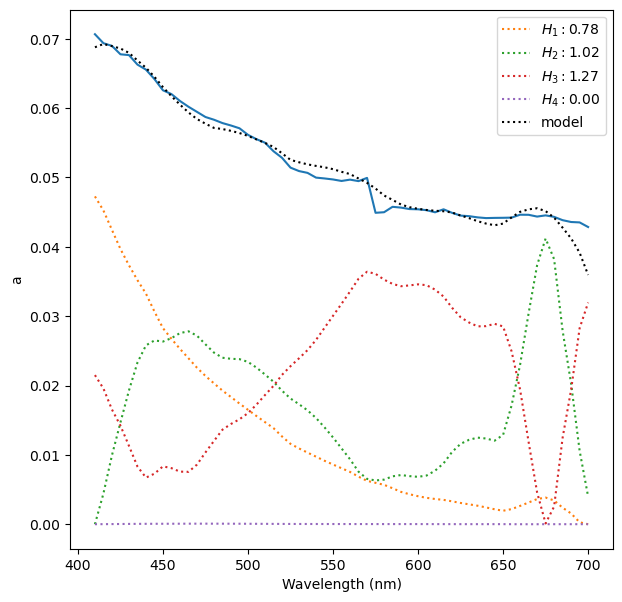

In [14]:
show_spec(idx)

----

# Another outlier region

In [18]:
out2 = (NMF_chl < 0.1) & (Tara_chlA > 1)
np.sum(out2)

210

In [19]:
all_idx2 = np.where(out2)[0]
idx2 = all_idx2[0]

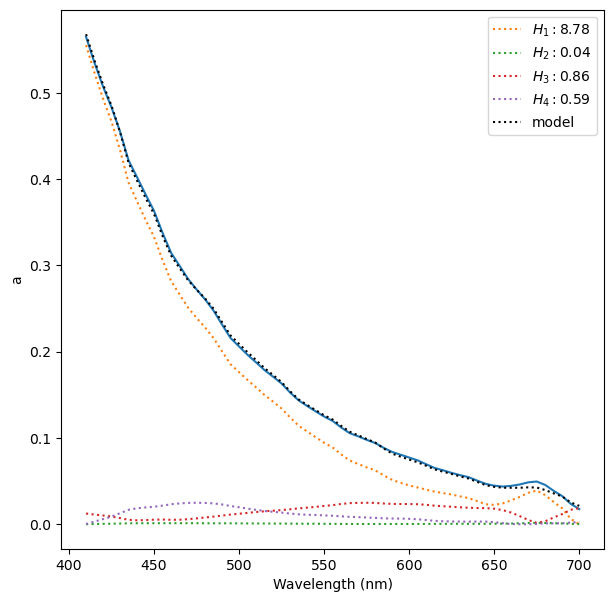

In [22]:
show_spec(idx2)